# Monoid-165 Unembedding Analysis

## Setup & Load

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import math
import numpy as np
import torch
import matplotlib.pyplot as plt

from core.data import generate_mod_mult_dataset, get_device
from core.checkpoint import load_model, checkpoint_path
from core.algebra import (
    get_jclass_elements, local_inverse_map,
    build_multi_log_table, character,
)
from experiments.character_fitting import (
    run_jclass_character_fit, plot_character_fit,
    run_all_fits, EXPERIMENT_SPECS_165,
)

In [2]:
P = 165
seed = 1
embed_dim = 128
mlp_dim = 512
n_heads = 4

device = torch.device("cpu")
print(f"P: {P}, device: {device}")

P: 165, device: cpu


In [3]:
ckpt = checkpoint_path("../experiments", P, embed_dim, n_heads, mlp_dim, seed)
model, checkpoint = load_model(ckpt, device)
print(f"Loaded: {ckpt}")

all_inputs, all_targets = generate_mod_mult_dataset(P)

Loaded: ../experiments/P165_d128_h4_mlp512_s1.pt


## Analysis 1 – Character Fitting

In [4]:
# Run all character fits for P=165 (Table 3) — uses our library
all_results = run_all_fits(model, P, device)

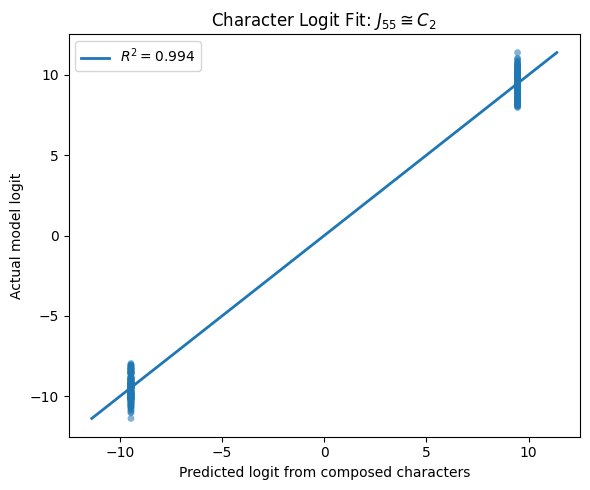

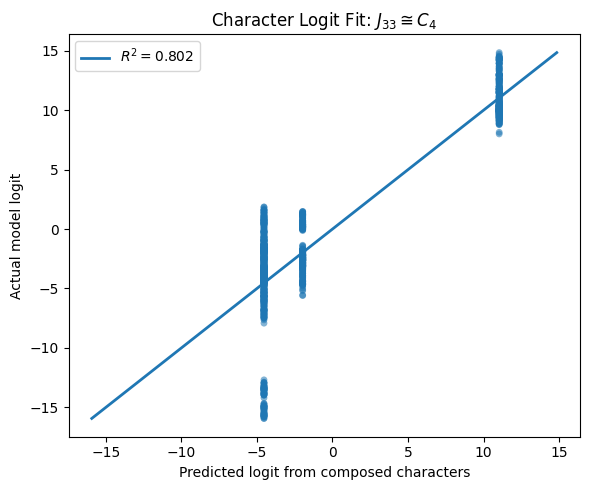

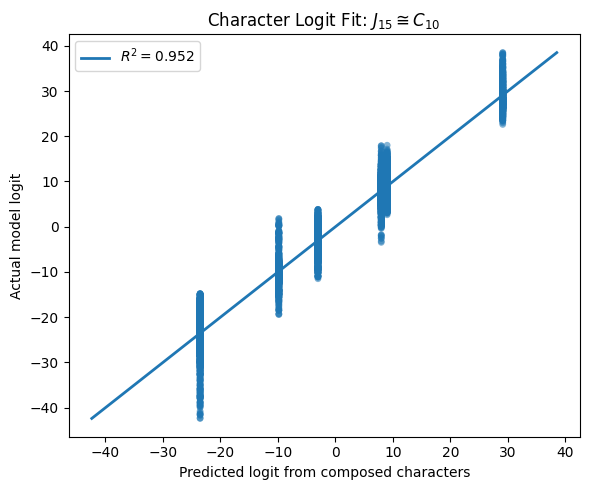

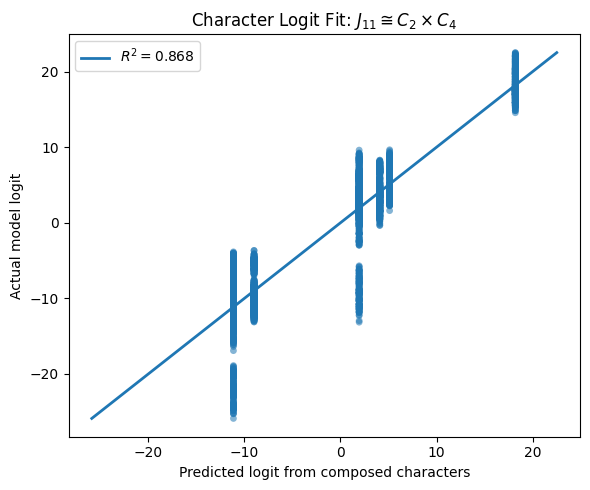

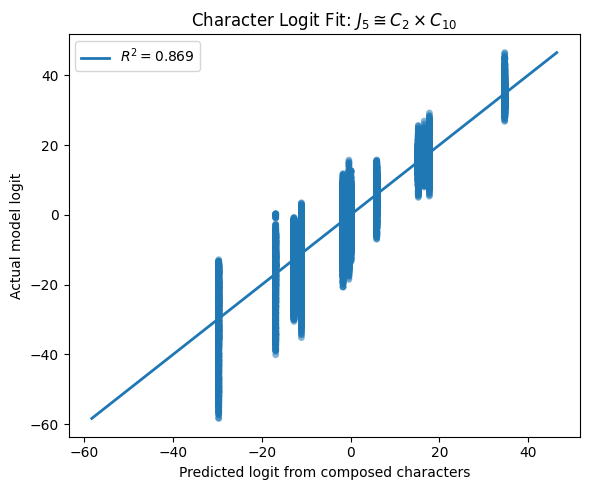

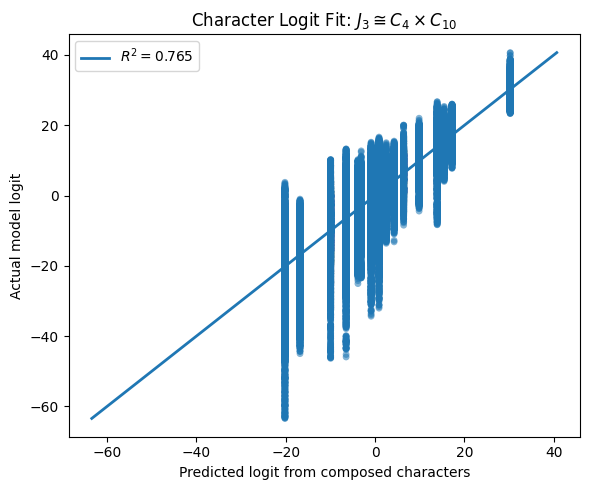

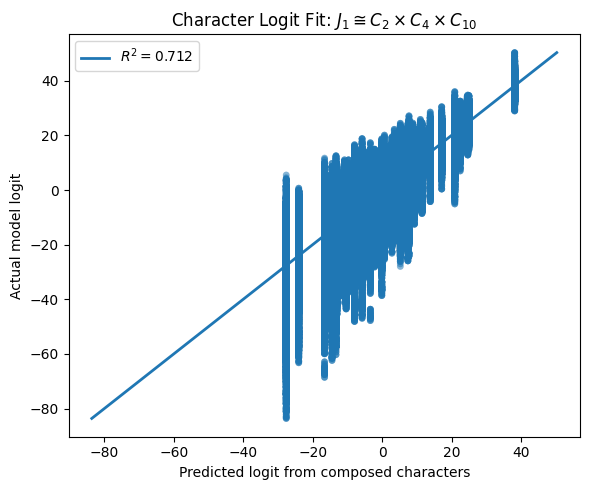

In [5]:
for name, result in all_results.items():
    plot_character_fit(result)
    plt.show()

In [6]:
print("\n" + "=" * 56)
print("Summary (Table 3)")
print("=" * 56)
print(f"{'Class':<8} | {'Source':<13} | {'Freqs':<22} | {'R^2':>8}")
print("-" * 56)

for spec in EXPERIMENT_SPECS_165:
    name = f"J_{spec['j_class']}"
    result = all_results[name]
    source = f"J_{spec['left_j']}xJ_{spec['right_j']}"
    freqs = str(spec["key_freqs"])
    print(f"{name:<8} | {source:<13} | {freqs:<22} | {result['r2']:>8.4f}")

print("=" * 56)


Summary (Table 3)
Class    | Source        | Freqs                  |      R^2
--------------------------------------------------------
J_55     | J_5xJ_11      | [1]                    |   0.9941
J_33     | J_3xJ_11      | [1, 2, 3]              |   0.8017
J_15     | J_3xJ_5       | [2, 3, 7, 8]           |   0.9524
J_11     | J_1xJ_11      | [(0, 1), (0, 2), (0, 3), (1, 0)] |   0.8675
J_5      | J_1xJ_5       | [(0, 2), (0, 3), (0, 7), (0, 8), (1, 0)] |   0.8692
J_3      | J_1xJ_3       | [(0, 2), (0, 3), (0, 7), (0, 8), (1, 0), (2, 0), (3, 0)] |   0.7651
J_1      | J_1xJ_1       | [(0, 0, 2), (0, 0, 3), (0, 0, 7), (0, 0, 8), (0, 1, 0), (0, 2, 0), (0, 3, 0), (1, 0, 0)] |   0.7115


## Verify algebra helpers

In [7]:
# Verify log table for J_15
j = 15
log_table, generators, orders, primes = build_multi_log_table(j, P)
J_15 = get_jclass_elements(j, P)
inv_map, e_J = local_inverse_map(J_15, P)

print(f"J_{j} elements: {J_15}")
print(f"Local identity e_J: {e_J}")
print(f"Generators: {generators}")
print(f"Orders: {orders}")
print(f"Log table: {log_table}")
print(f"\nInverse map:")
for c in J_15:
    print(f"  {c} * {inv_map[c]} = {(c * inv_map[c]) % P} (should be {e_J})")

J_15 elements: [15, 30, 45, 60, 75, 90, 105, 120, 135, 150]
Local identity e_J: 45
Generators: [2]
Orders: [10]
Log table: {45: (0,), 90: (1,), 15: (2,), 30: (3,), 60: (4,), 120: (5,), 75: (6,), 150: (7,), 135: (8,), 105: (9,)}

Inverse map:
  15 * 135 = 45 (should be 45)
  30 * 150 = 45 (should be 45)
  45 * 45 = 45 (should be 45)
  60 * 75 = 45 (should be 45)
  75 * 60 = 45 (should be 45)
  90 * 105 = 45 (should be 45)
  105 * 90 = 45 (should be 45)
  120 * 120 = 45 (should be 45)
  135 * 15 = 45 (should be 45)
  150 * 30 = 45 (should be 45)


In [8]:
# Test character computation
freq_vec = (2,)
for z in J_15:
    chi = character(z, freq_vec, orders, log_table)
    t = log_table[z]
    print(f"  chi_{freq_vec}({z}) = {chi:.4f}  (t={t})")

  chi_(2,)(15) = -1.6180  (t=(2,))
  chi_(2,)(30) = -1.6180  (t=(3,))
  chi_(2,)(45) = 2.0000  (t=(0,))
  chi_(2,)(60) = 0.6180  (t=(4,))
  chi_(2,)(75) = 0.6180  (t=(6,))
  chi_(2,)(90) = 0.6180  (t=(1,))
  chi_(2,)(105) = 0.6180  (t=(9,))
  chi_(2,)(120) = 2.0000  (t=(5,))
  chi_(2,)(135) = -1.6180  (t=(8,))
  chi_(2,)(150) = -1.6180  (t=(7,))


## Misc

In [9]:
for i in range(P):
    if (i ** 2 % P == i):
        print(f"{i} (J-class: J_{np.gcd(i, P)})")

0 (J-class: J_165)
1 (J-class: J_1)
45 (J-class: J_15)
55 (J-class: J_55)
66 (J-class: J_33)
100 (J-class: J_5)
111 (J-class: J_3)
121 (J-class: J_11)
